##**Step 3: Data Preprocessing, Applied EDA annd Feature Engineering**


This section prepares the Bank Account Fraud dataset for model development. The goal is to transform the raw Base dataset into a clean, analysis-ready, and modeling-ready dataset while preserving important fraud signals. Since fraud detection datasets often contain rare positive cases, extreme values, behavioral anomalies, and temporal variation, preprocessing must be done carefully. The project will use Base.csv as the primary dataset for preprocessing, EDA, feature engineering, feature selection, and dimensionality reduction. Variant II.csv will be processed using the same logic and retained as a separate robustness and fairness stress-test dataset.


The main objective of this step is not only to clean the data, but also to understand fraud patterns, create meaningful domain-derived features, document all transformations, and prepare a reproducible preprocessing pipeline that can be used consistently in model training and evaluation.

**a. Preprocessing Strategy**


The preprocessing strategy follows five principles. First, the target variable fraud_bool will be preserved and separated from the input features. Second, Base and Variant II will not be merged because each variant represents a separate controlled setting in the BAF suite. Third, missing values and sentinel values such as -1 will be handled carefully because they may represent unavailable, unknown, or not-applicable information rather than ordinary numeric values. Fourth, outliers will not be automatically removed because unusual values may be meaningful fraud signals. Instead, they will be reviewed, flagged, transformed, or handled using robust scaling where appropriate. Fifth, the same preprocessing and feature engineering logic will be applied to both Base and Variant II to ensure fair comparison.

**b. Initial Data Quality Validation**

Before applying transformations, the dataset is checked again for missing values, duplicate records, feature consistency, and target validity. This confirms whether the dataset is ready for preprocessing and ensures that the target variable contains only the expected binary values.

The initial quality validation is important because any issue at this stage can affect EDA, feature engineering, and model training. Since this is a fraud detection problem, even small data quality issues can distort class imbalance, fraud rate estimates, and evaluation metrics.

In [ ]:
#Data quality validation

datasets = {
    "Base": base_df,
    "Variant II": variant_ii_df
}

quality_rows = []

for name, data in datasets.items():
    quality_rows.append({
        "dataset": name,
        "rows": data.shape[0],
        "columns": data.shape[1],
        "missing_cells": int(data.isna().sum().sum()),
        "duplicate_rows": int(data.duplicated().sum()),
        "target_unique_values": sorted(data[TARGET_COL].dropna().unique().tolist()),
        "fraud_count": int(data[TARGET_COL].sum()),
        "fraud_rate_percent": round(data[TARGET_COL].mean() * 100, 4)
    })

quality_summary = pd.DataFrame(quality_rows)
display(quality_summary)

# Confirm that both datasets have the same columns
base_columns = set(base_df.columns)
variant_columns = set(variant_ii_df.columns)

print("Columns in Base but not in Variant II:", base_columns - variant_columns)
print("Columns in Variant II but not in Base:", variant_columns - base_columns)
print("Same column structure:", base_columns == variant_columns)

,dataset,rows,columns,missing_cells,duplicate_rows,target_unique_values,fraud_count,fraud_rate_percent
0,Base,1000000,32,0,0,"[0, 1]",11029,1.1029
1,Variant II,1000000,32,0,0,"[0, 1]",11029,1.1029


Columns in Base but not in Variant II: set()
Columns in Variant II but not in Base: set()
Same column structure: True


**c. Sentinel Value Review and Missing-Value Strategy**


Although the dataset may not contain blank missing values, some numerical fields contain -1, which may represent unavailable, unknown, or not-applicable information. These values should not be treated blindly as ordinary negative values. For example, a -1 value in address months, bank months, session length, or device email count may indicate that the information was missing or not captured.


The preprocessing strategy will create missing-indicator flags for selected variables where -1 appears, then replace -1 with NaN so that the model can distinguish between “unknown” and valid numeric values. This preserves information while allowing the imputation pipeline to handle the missing numeric values properly.

In [ ]:
# Sentinel value review

numeric_cols = base_df.select_dtypes(include=np.number).columns.tolist()

sentinel_rows = []

for col in numeric_cols:
    if col == TARGET_COL:
        continue

    base_neg_one = int((base_df[col] == -1).sum())
    variant_neg_one = int((variant_ii_df[col] == -1).sum())

    if base_neg_one > 0 or variant_neg_one > 0:
        sentinel_rows.append({
            "column": col,
            "base_negative_one_count": base_neg_one,
            "base_negative_one_percent": round(base_neg_one / len(base_df) * 100, 4),
            "variant_ii_negative_one_count": variant_neg_one,
            "variant_ii_negative_one_percent": round(variant_neg_one / len(variant_ii_df) * 100, 4)
        })

sentinel_summary = pd.DataFrame(sentinel_rows).sort_values(
    "base_negative_one_percent", ascending=False
)

display(sentinel_summary)

,column,base_negative_one_count,base_negative_one_percent,variant_ii_negative_one_count,variant_ii_negative_one_percent
0,prev_address_months_count,712920,71.2920,759415,75.9415
3,bank_months_count,253635,25.3635,241872,24.1872
1,current_address_months_count,4254,0.4254,3488,0.3488
4,session_length_in_minutes,2015,0.2015,2277,0.2277
2,credit_risk_score,488,0.0488,435,0.0435
5,device_distinct_emails_8w,359,0.0359,336,0.0336


**d. Outlier Review and Treatment Strategy**

Outliers are expected in fraud detection datasets because unusual behavior may be part of the fraud signal. For this reason, outliers will not be automatically removed. Instead, the project will identify variables with extreme values, review whether these values are plausible, and handle them using appropriate transformations.

The main treatment will be to use robust scaling during preprocessing and create log-transformed versions of highly skewed behavioral and amount-related variables. This approach reduces the influence of extreme values for models sensitive to scale, while preserving potentially meaningful fraud signals.

In [ ]:
# IQR-based outlier summary for Base dataset

outlier_rows = []

for col in numeric_cols:
    if col == TARGET_COL:
        continue

    q1 = base_df[col].quantile(0.25)
    q3 = base_df[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = int(((base_df[col] < lower_bound) | (base_df[col] > upper_bound)).sum())
    outlier_percent = outlier_count / len(base_df) * 100

    outlier_rows.append({
        "column": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count,
        "outlier_percent": round(outlier_percent, 4)
    })

outlier_summary_base = pd.DataFrame(outlier_rows).sort_values(
    "outlier_percent", ascending=False
)

display(outlier_summary_base.head(20))

,column,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percent
19,proposed_credit_limit,200.000000,500.000000,300.000000,-250.000000,950.000000,241742,24.1742
18,has_other_cards,0.000000,0.000000,0.000000,0.000000,0.000000,222988,22.2988
6,intended_balcon_amount,-1.181488,4.984176,6.165664,-10.429984,14.232671,222702,22.2702
11,bank_branch_count_8w,1.000000,25.000000,24.000000,-35.000000,61.000000,175243,17.5243
2,prev_address_months_count,-1.000000,12.000000,13.000000,-20.500000,31.500000,157320,15.7320
16,phone_mobile_valid,1.000000,1.000000,0.000000,1.000000,1.000000,110324,11.0324
5,days_since_request,0.007193,0.026331,0.019137,-0.021513,0.055037,94834,9.4834
21,session_length_in_minutes,3.103053,8.866131,5.763078,-5.541564,17.510748,78789,7.8789
7,zip_count_4w,894.000000,1944.000000,1050.000000,-681.000000,3519.000000,59871,5.9871
3,current_address_months_count,19.000000,130.000000,111.000000,-147.500000,296.500000,41001,4.1001


**e. Applied EDA - Target Distribution**

The first EDA step examines the distribution of the target variable. This confirms the degree of class imbalance and supports the earlier decision to use PR-AUC, recall, precision, and top-K fraud capture instead of accuracy alone.

,class,label,count,percent
0,0,Legitimate,988971,98.8971
1,1,Fraud,11029,1.1029


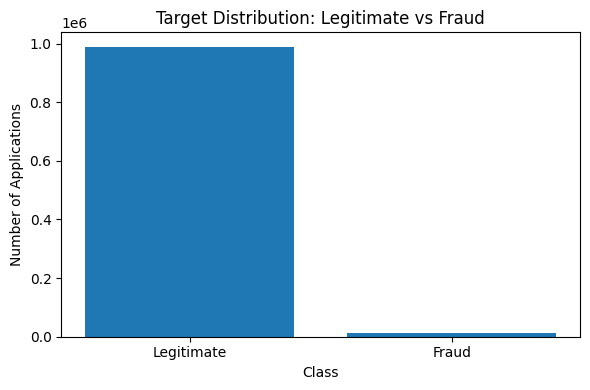

In [ ]:
# Target distribution visual

import matplotlib.pyplot as plt

target_counts = base_df[TARGET_COL].value_counts().sort_index()
target_percent = base_df[TARGET_COL].value_counts(normalize=True).sort_index() * 100

target_distribution = pd.DataFrame({
    "class": target_counts.index,
    "label": ["Legitimate", "Fraud"],
    "count": target_counts.values,
    "percent": target_percent.round(4).values
})

display(target_distribution)

plt.figure(figsize=(6, 4))
plt.bar(target_distribution["label"], target_distribution["count"])
plt.title("Target Distribution: Legitimate vs Fraud")
plt.xlabel("Class")
plt.ylabel("Number of Applications")
plt.tight_layout()
plt.show()

**f. Applied EDA - Fraud Rate by Month**

The month variable allows the project to examine temporal patterns. This is important because fraud behavior may change over time. A time-based validation strategy will be considered later to simulate a real-world setup where models are trained on historical applications and tested on future applications.


,month,total_applications,fraud_count,fraud_rate,fraud_rate_percent
0,0,132440,1500,0.011326,1.132588
1,1,127620,1198,0.009387,0.938724
2,2,136979,1198,0.008746,0.874587
3,3,150936,1392,0.009222,0.922245
4,4,127691,1452,0.011371,1.137120
5,5,119323,1411,0.011825,1.182505
6,6,108168,1450,0.013405,1.340507
7,7,96843,1428,0.014746,1.474552


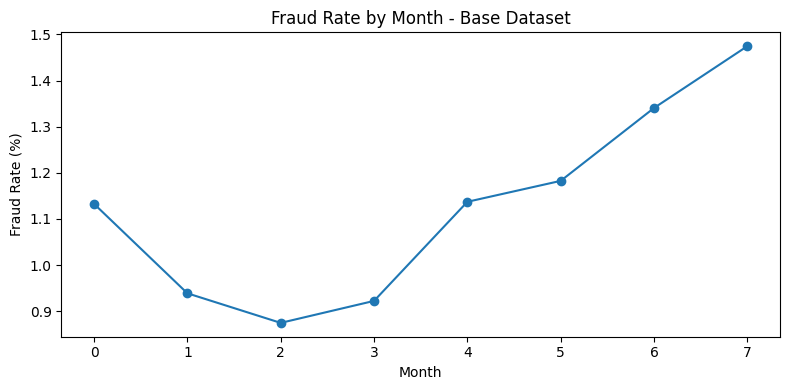

In [ ]:
# Fraud rate by month

monthly_fraud = base_df.groupby("month").agg(
    total_applications=(TARGET_COL, "count"),
    fraud_count=(TARGET_COL, "sum"),
    fraud_rate=(TARGET_COL, "mean")
).reset_index()

monthly_fraud["fraud_rate_percent"] = monthly_fraud["fraud_rate"] * 100

display(monthly_fraud)

plt.figure(figsize=(8, 4))
plt.plot(monthly_fraud["month"], monthly_fraud["fraud_rate_percent"], marker="o")
plt.title("Fraud Rate by Month - Base Dataset")
plt.xlabel("Month")
plt.ylabel("Fraud Rate (%)")
plt.tight_layout()
plt.show()

**g. Applied EDA - Numerical Feature Relationships**

This section examines selected numerical variables that are likely to be relevant to fraud detection. These include income, name-email similarity, customer age, credit risk score, velocity indicators, session length, proposed credit limit, and device-related variables. The goal is to identify patterns, distributions, and possible differences between fraudulent and legitimate applications.

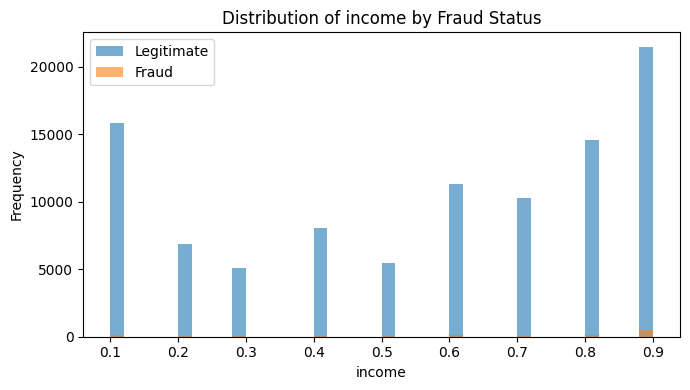

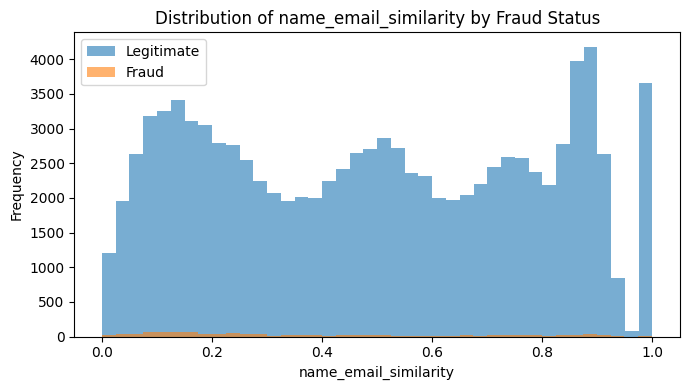

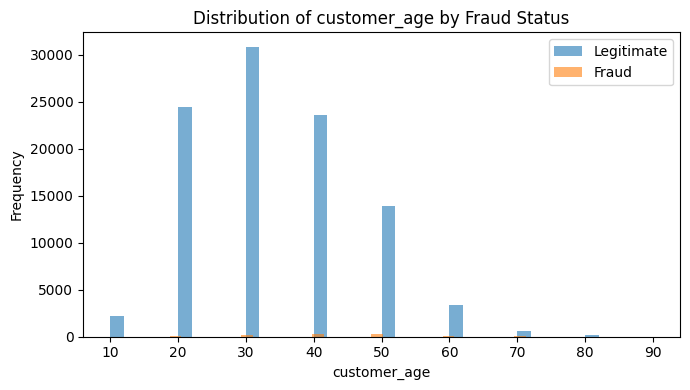

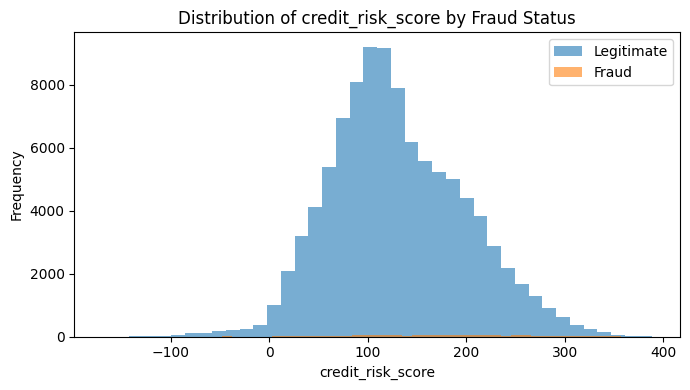

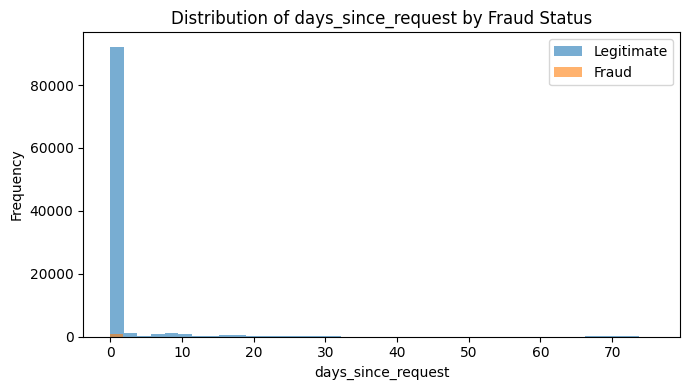

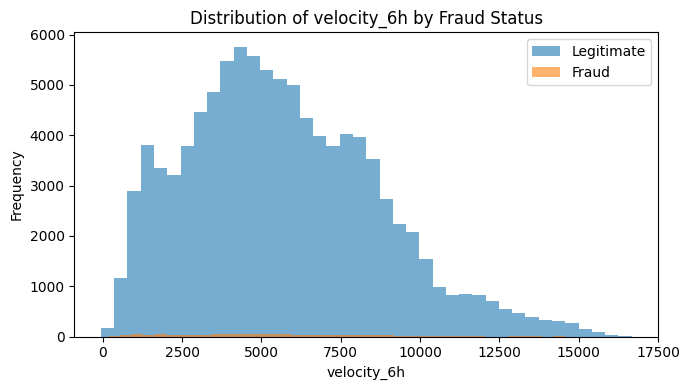

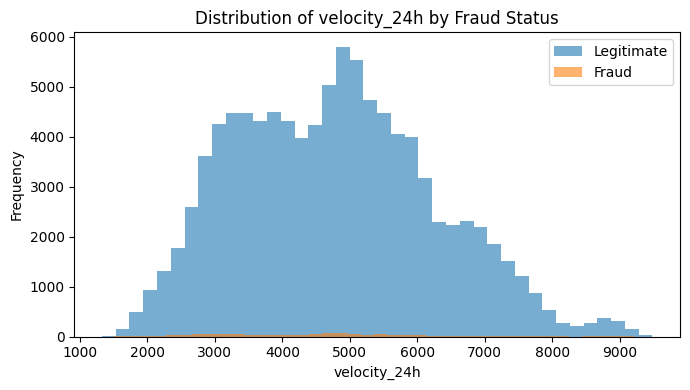

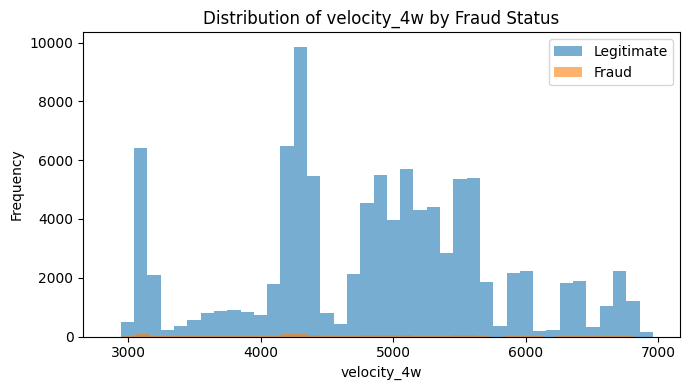

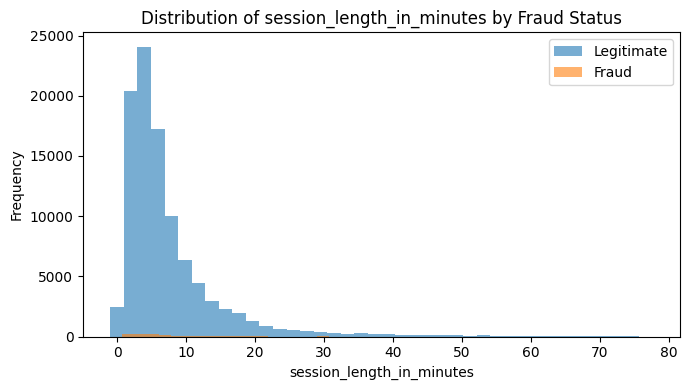

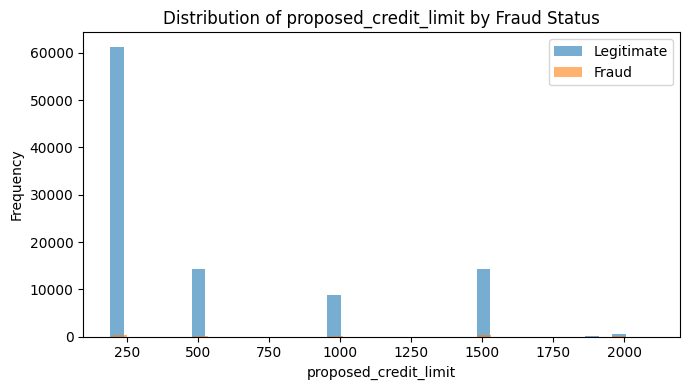

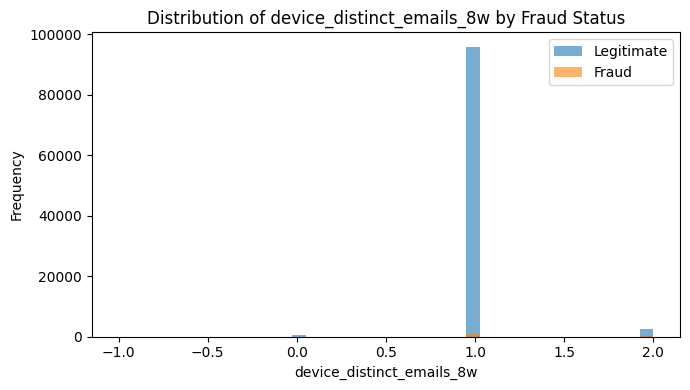

In [ ]:
# Numerical EDA using a manageable sample

eda_sample = base_df.sample(
    n=min(100000, len(base_df)),
    random_state=SEED
)

selected_numeric_features = [
    "income",
    "name_email_similarity",
    "customer_age",
    "credit_risk_score",
    "days_since_request",
    "velocity_6h",
    "velocity_24h",
    "velocity_4w",
    "session_length_in_minutes",
    "proposed_credit_limit",
    "device_distinct_emails_8w"
]

for col in selected_numeric_features:
    if col in eda_sample.columns:
        plt.figure(figsize=(7, 4))
        plt.hist(
            eda_sample.loc[eda_sample[TARGET_COL] == 0, col].dropna(),
            bins=40,
            alpha=0.6,
            label="Legitimate"
        )
        plt.hist(
            eda_sample.loc[eda_sample[TARGET_COL] == 1, col].dropna(),
            bins=40,
            alpha=0.6,
            label="Fraud"
        )
        plt.title(f"Distribution of {col} by Fraud Status")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.legend()
        plt.tight_layout()
        plt.show()

**h. Applied EDA - Categorical Feature Fraud Rates**


Categorical variables may reveal important fraud patterns by payment type, employment status, housing status, source, and device operating system. Instead of only counting categories, this analysis calculates fraud rate by category, which is more useful for fraud detection.

,payment_type,total_applications,fraud_count,fraud_rate,fraud_rate_percent
2,AC,252071,4209,0.016698,1.669768
1,AB,370554,4169,0.011251,1.125072
3,AD,118837,1286,0.010822,1.082155
0,AA,258249,1364,0.005282,0.528172
4,AE,289,1,0.003460,0.346021


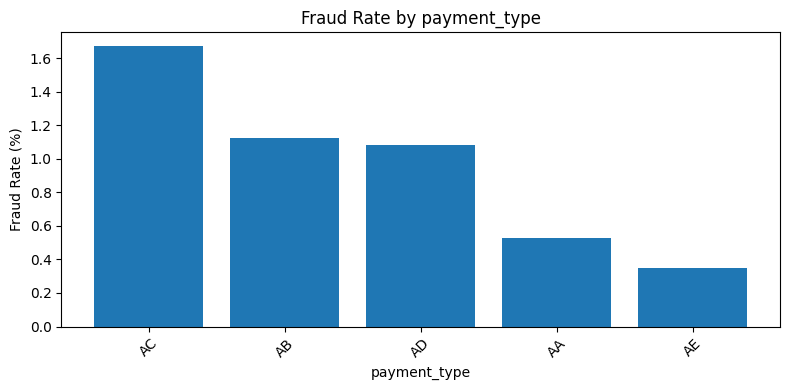

,employment_status,total_applications,fraud_count,fraud_rate,fraud_rate_percent
2,CC,37758,932,0.024684,2.468351
6,CG,453,7,0.015453,1.545254
0,CA,730252,8899,0.012186,1.218620
1,CB,138288,953,0.006891,0.689142
3,CD,26522,100,0.003770,0.377045
4,CE,22693,53,0.002336,0.233552
5,CF,44034,85,0.001930,0.193033


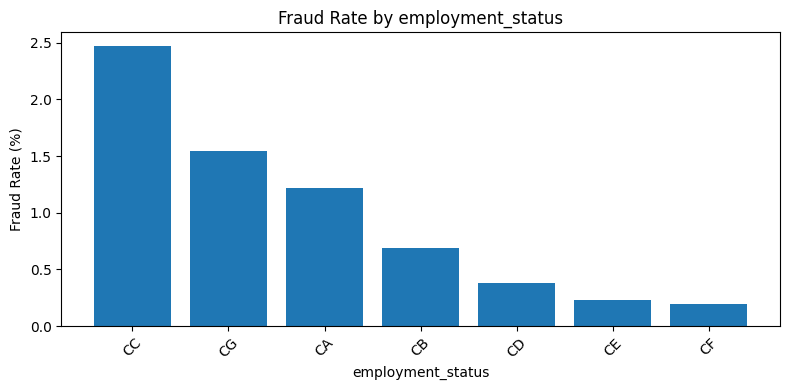

,housing_status,total_applications,fraud_count,fraud_rate,fraud_rate_percent
0,BA,169675,6357,0.037466,3.746574
3,BD,26161,226,0.008639,0.863881
2,BC,372143,2288,0.006148,0.614817
1,BB,260965,1568,0.006008,0.600847
5,BF,1669,7,0.004194,0.419413
6,BG,252,1,0.003968,0.396825
4,BE,169135,582,0.003441,0.344104


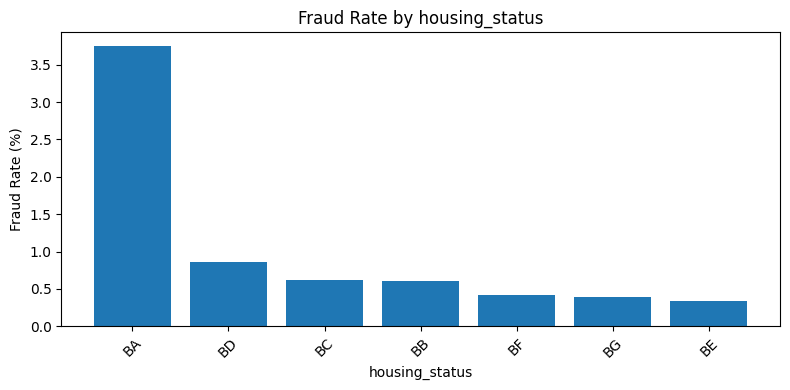

,source,total_applications,fraud_count,fraud_rate,fraud_rate_percent
1,TELEAPP,7048,112,0.015891,1.589103
0,INTERNET,992952,10917,0.010994,1.099449


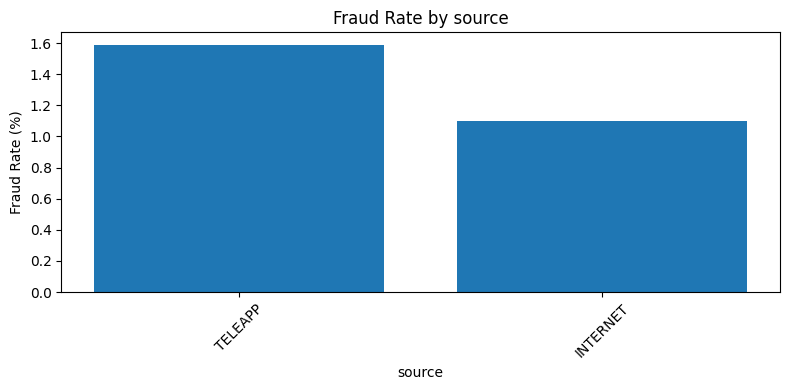

,device_os,total_applications,fraud_count,fraud_rate,fraud_rate_percent
3,windows,263506,6507,0.024694,2.469393
1,macintosh,53826,752,0.013971,1.397094
4,x11,7228,81,0.011206,1.120642
2,other,342728,1974,0.005760,0.575967
0,linux,332712,1715,0.005155,0.515461


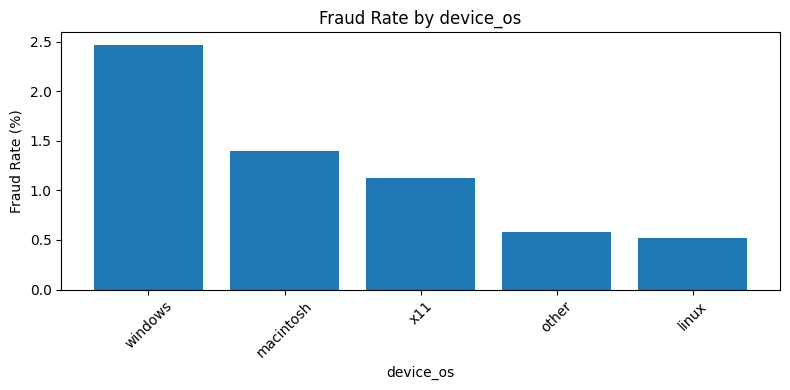

In [ ]:
# Fraud rate by categorical features

categorical_cols = base_df.select_dtypes(exclude=np.number).columns.tolist()

for col in categorical_cols:
    fraud_by_category = base_df.groupby(col).agg(
        total_applications=(TARGET_COL, "count"),
        fraud_count=(TARGET_COL, "sum"),
        fraud_rate=(TARGET_COL, "mean")
    ).reset_index()

    fraud_by_category["fraud_rate_percent"] = fraud_by_category["fraud_rate"] * 100
    fraud_by_category = fraud_by_category.sort_values("fraud_rate_percent", ascending=False)

    display(fraud_by_category)

    plt.figure(figsize=(8, 4))
    plt.bar(
        fraud_by_category[col].astype(str),
        fraud_by_category["fraud_rate_percent"]
    )
    plt.title(f"Fraud Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Fraud Rate (%)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

**i. Applied EDA - Correlation Review**

Correlation analysis helps identify relationships among numerical variables and can reveal redundancy or potential multicollinearity. This is especially useful for interpretable models such as Logistic Regression. Highly correlated variables may not need to be removed immediately, but they should be documented and considered during feature selection.

,fraud_bool
fraud_bool,1.000000
credit_risk_score,0.070624
proposed_credit_limit,0.068907
customer_age,0.062959
income,0.045079
device_distinct_emails_8w,0.035704
session_length_in_minutes,0.008999
days_since_request,0.000567
velocity_24h,-0.011183
velocity_4w,-0.011536


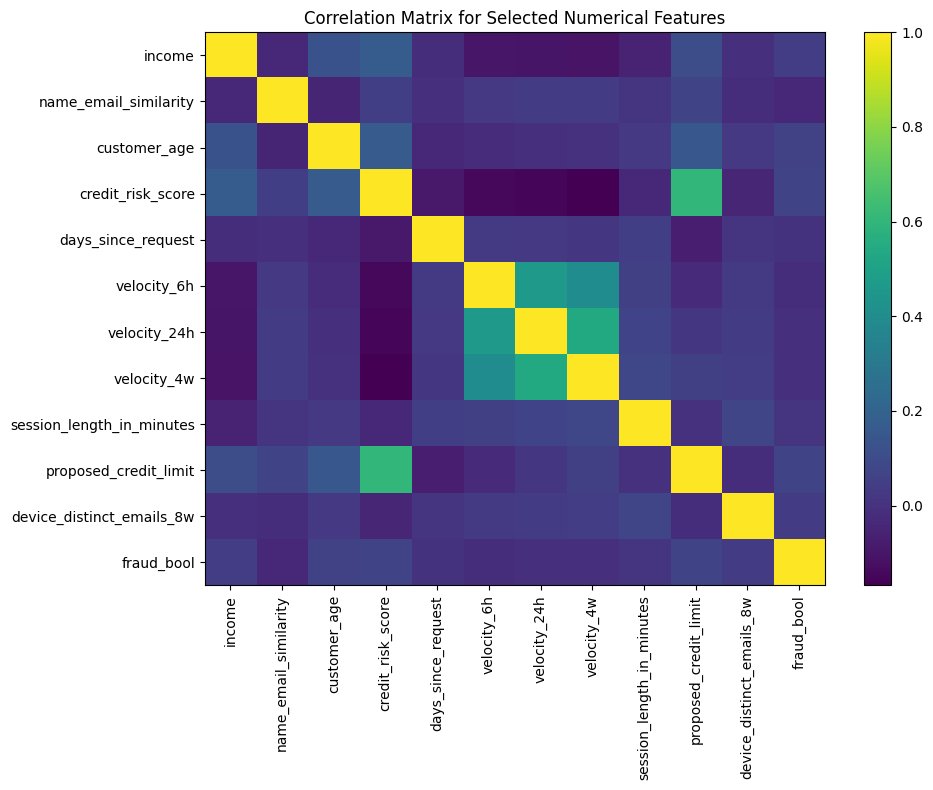

In [ ]:
# Correlation review for numerical features

corr_features = [
    col for col in selected_numeric_features
    if col in base_df.columns
]

corr_matrix = base_df[corr_features + [TARGET_COL]].corr(numeric_only=True)

display(corr_matrix[TARGET_COL].sort_values(ascending=False))

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Correlation Matrix for Selected Numerical Features")
plt.tight_layout()
plt.show()

**j. Domain-Derived Feature Engineering**

Feature engineering is used to create additional variables that reflect fraud-domain knowledge. In account fraud detection, suspicious behavior may appear in identity inconsistency, unusual velocity, weak address history, device reuse, session behavior, and financial exposure patterns.

The engineered features below are designed to improve model learning and business interpretability. Examples include identity mismatch indicators, address instability flags, velocity ratios, log-transformed behavioral variables, age groups, and credit-risk bands. These features will help the model capture non-linear patterns and allow the final presentation to explain fraud drivers in business terms.

In [ ]:
# Domain-derived feature engineering

def create_domain_features(df):
    """
    Creates fraud-domain features for account application fraud detection.
    This function is applied consistently to Base and Variant II.
    """

    data = df.copy()

    # 1. Sentinel indicators for selected fields where -1 may mean unknown/not applicable
    sentinel_cols = [
        "prev_address_months_count",
        "current_address_months_count",
        "bank_months_count",
        "session_length_in_minutes",
        "device_distinct_emails_8w"
    ]

    for col in sentinel_cols:
        if col in data.columns:
            data[f"{col}_unknown_flag"] = (data[col] == -1).astype(int)
            data[col] = data[col].replace(-1, np.nan)

    # 2. Identity consistency features
    if "name_email_similarity" in data.columns:
        data["name_email_mismatch_score"] = 1 - data["name_email_similarity"]
        data["low_name_email_similarity_flag"] = (data["name_email_similarity"] < 0.20).astype(int)

    if "date_of_birth_distinct_emails_4w" in data.columns:
        data["multiple_emails_same_dob_flag"] = (
            data["date_of_birth_distinct_emails_4w"] >= 3
        ).astype(int)

    # 3. Address stability features
    if "current_address_months_count" in data.columns:
        data["short_current_address_flag"] = (
            data["current_address_months_count"] <= 6
        ).astype(int)

    if "prev_address_months_count" in data.columns and "current_address_months_count" in data.columns:
        data["total_known_address_months"] = (
            data["prev_address_months_count"].fillna(0)
            + data["current_address_months_count"].fillna(0)
        )

    # 4. Velocity ratio features
    if "velocity_6h" in data.columns and "velocity_24h" in data.columns:
        data["velocity_6h_to_24h_ratio"] = data["velocity_6h"] / (data["velocity_24h"] + 1)

    if "velocity_24h" in data.columns and "velocity_4w" in data.columns:
        data["velocity_24h_to_4w_ratio"] = data["velocity_24h"] / (data["velocity_4w"] + 1)

    # 5. Financial exposure features
    if "proposed_credit_limit" in data.columns:
        data["log_proposed_credit_limit"] = np.log1p(data["proposed_credit_limit"].clip(lower=0))

    if "intended_balcon_amount" in data.columns:
        data["intended_balcon_negative_flag"] = (data["intended_balcon_amount"] < 0).astype(int)
        data["log_abs_intended_balcon_amount"] = np.log1p(data["intended_balcon_amount"].abs())

    # 6. Session behavior features
    if "session_length_in_minutes" in data.columns:
        data["log_session_length"] = np.log1p(data["session_length_in_minutes"].clip(lower=0))
        data["very_short_session_flag"] = (data["session_length_in_minutes"] < 1).astype(int)

    # 7. Device behavior features
    if "device_distinct_emails_8w" in data.columns:
        data["multiple_emails_per_device_flag"] = (
            data["device_distinct_emails_8w"] > 1
        ).astype(int)

    # 8. Age and credit-risk bins for EDA and possible model use
    if "customer_age" in data.columns:
        data["customer_age_group"] = pd.cut(
            data["customer_age"],
            bins=[0, 20, 30, 40, 50, 60, 70, 100],
            labels=["<20", "20-29", "30-39", "40-49", "50-59", "60-69", "70+"],
            include_lowest=True
        )

    if "credit_risk_score" in data.columns:
        data["credit_risk_band"] = pd.qcut(
            data["credit_risk_score"].rank(method="first"),
            q=5,
            labels=["very_low", "low", "medium", "high", "very_high"]
        )

    # 9. Channel-device interaction
    if "source" in data.columns and "device_os" in data.columns:
        data["source_device_os"] = data["source"].astype(str) + "_" + data["device_os"].astype(str)

    return data


base_fe = create_domain_features(base_df)
variant_ii_fe = create_domain_features(variant_ii_df)

print("Base original shape:", base_df.shape)
print("Base with engineered features:", base_fe.shape)
print("Variant II original shape:", variant_ii_df.shape)
print("Variant II with engineered features:", variant_ii_fe.shape)

Base original shape: (1000000, 32)
Base with engineered features: (1000000, 53)
Variant II original shape: (1000000, 32)
Variant II with engineered features: (1000000, 53)


**k. EDA of Engineered Features**

After creating domain-derived features, the next step is to check whether these new features show meaningful fraud patterns. This is important because feature engineering should be justified by evidence, not only by intuition.

In [ ]:
# Fraud rate by selected engineered features

engineered_categorical_features = [
    "low_name_email_similarity_flag",
    "multiple_emails_same_dob_flag",
    "short_current_address_flag",
    "intended_balcon_negative_flag",
    "very_short_session_flag",
    "multiple_emails_per_device_flag",
    "customer_age_group",
    "credit_risk_band",
    "source_device_os"
]

for col in engineered_categorical_features:
    if col in base_fe.columns:
        feature_fraud_rate = base_fe.groupby(col, observed=True).agg(
            total_applications=(TARGET_COL, "count"),
            fraud_count=(TARGET_COL, "sum"),
            fraud_rate=(TARGET_COL, "mean")
        ).reset_index()

        feature_fraud_rate["fraud_rate_percent"] = feature_fraud_rate["fraud_rate"] * 100
        feature_fraud_rate = feature_fraud_rate.sort_values("fraud_rate_percent", ascending=False)

        display(feature_fraud_rate.head(20))

,low_name_email_similarity_flag,total_applications,fraud_count,fraud_rate,fraud_rate_percent
1,1,221045,4214,0.019064,1.906399
0,0,778955,6815,0.008749,0.874890


,multiple_emails_same_dob_flag,total_applications,fraud_count,fraud_rate,fraud_rate_percent
0,0,51430,1824,0.035466,3.546568
1,1,948570,9205,0.009704,0.970408


,short_current_address_flag,total_applications,fraud_count,fraud_rate,fraud_rate_percent
0,0,905065,10680,0.011800,1.180026
1,1,94935,349,0.003676,0.367620


,intended_balcon_negative_flag,total_applications,fraud_count,fraud_rate,fraud_rate_percent
1,1,742523,9747,0.013127,1.312687
0,0,257477,1282,0.004979,0.497909


,very_short_session_flag,total_applications,fraud_count,fraud_rate,fraud_rate_percent
0,0,974129,10776,0.011062,1.106219
1,1,25871,253,0.009779,0.977929


,multiple_emails_per_device_flag,total_applications,fraud_count,fraud_rate,fraud_rate_percent
1,1,25302,1035,0.040906,4.090586
0,0,974698,9994,0.010253,1.025343


,customer_age_group,total_applications,fraud_count,fraud_rate,fraud_rate_percent
6,70+,1373,68,0.049527,4.952658
5,60-69,6517,263,0.040356,4.035599
4,50-59,34770,1149,0.033046,3.304573
3,40-49,140353,2805,0.019985,1.998532
2,30-39,238712,2876,0.012048,1.204799
1,20-29,311433,2589,0.008313,0.831318
0,<20,266842,1279,0.004793,0.479310


,credit_risk_band,total_applications,fraud_count,fraud_rate,fraud_rate_percent
4,very_high,200000,4899,0.024495,2.4495
3,high,200000,2260,0.011300,1.1300
1,low,200000,1340,0.006700,0.6700
2,medium,200000,1305,0.006525,0.6525
0,very_low,200000,1225,0.006125,0.6125


,source_device_os,total_applications,fraud_count,fraud_rate,fraud_rate_percent
8,TELEAPP_windows,501,29,0.057884,5.788423
6,TELEAPP_macintosh,227,10,0.044053,4.405286
3,INTERNET_windows,263005,6478,0.024631,2.463071
1,INTERNET_macintosh,53599,742,0.013844,1.384354
7,TELEAPP_other,5416,64,0.011817,1.181684
4,INTERNET_x11,7200,81,0.011250,1.125000
5,TELEAPP_linux,876,9,0.010274,1.027397
2,INTERNET_other,337312,1910,0.005662,0.566241
0,INTERNET_linux,331836,1706,0.005141,0.514109
9,TELEAPP_x11,28,0,0.000000,0.000000


**l. Preprocessing Pipeline for Modeling**

The preprocessing pipeline prepares the dataset for model training. Numerical features will be imputed using the median and scaled using RobustScaler to reduce the influence of outliers. Categorical features will be imputed using the most frequent category and encoded using one-hot encoding. This approach allows the same preprocessing logic to be applied consistently to Base and Variant II.

The target variable and raw month variable will be handled carefully. The target variable must not be included as a predictor. The month variable may be used for temporal splitting and drift analysis. For modeling, it can be retained as a predictor only if justified, but temporal validation should prevent leakage by testing on later months.

In [ ]:
# Preprocessing pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer

# Separate target
X_base = base_fe.drop(columns=[TARGET_COL])
y_base = base_fe[TARGET_COL]

X_variant_ii = variant_ii_fe.drop(columns=[TARGET_COL])
y_variant_ii = variant_ii_fe[TARGET_COL]

# Identify feature types after engineering
numeric_features = X_base.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_base.select_dtypes(exclude=np.number).columns.tolist()

print("Number of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

# Compatibility for different scikit-learn versions
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", onehot)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Preprocessing pipeline created.")

Number of numeric features: 44
Number of categorical features: 8
Preprocessing pipeline created.


**m. Time-Based Split for Realistic Validation**

Fraud detection models should be evaluated in a way that approximates real-world use. Since the dataset contains a month variable, the project will use earlier months for training and later months for validation/testing. This reduces the risk of overly optimistic results from random splitting and better reflects a realistic situation where a model is trained on historical applications and used on future applications.

The recommended split is:

Training set: months 0 to 5
Validation set: month 6
Test set: month 7
Variant II: separate robustness and fairness stress-test dataset

In [ ]:
# Time-based split

train_months = [0, 1, 2, 3, 4, 5]
valid_months = [6]
test_months = [7]

train_mask = base_fe["month"].isin(train_months)
valid_mask = base_fe["month"].isin(valid_months)
test_mask = base_fe["month"].isin(test_months)

X_train = base_fe.loc[train_mask].drop(columns=[TARGET_COL])
y_train = base_fe.loc[train_mask, TARGET_COL]

X_valid = base_fe.loc[valid_mask].drop(columns=[TARGET_COL])
y_valid = base_fe.loc[valid_mask, TARGET_COL]

X_test = base_fe.loc[test_mask].drop(columns=[TARGET_COL])
y_test = base_fe.loc[test_mask, TARGET_COL]

print("Training set:", X_train.shape, "Fraud rate:", round(y_train.mean() * 100, 4), "%")
print("Validation set:", X_valid.shape, "Fraud rate:", round(y_valid.mean() * 100, 4), "%")
print("Test set:", X_test.shape, "Fraud rate:", round(y_test.mean() * 100, 4), "%")

Training set: (794989, 52) Fraud rate: 1.0253 %
Validation set: (108168, 52) Fraud rate: 1.3405 %
Test set: (96843, 52) Fraud rate: 1.4746 %


**n. Feature Selection Using Mutual Information**

To satisfy the feature selection requirement, this project will use a filter-based method: mutual information. Mutual information helps estimate how much information each feature provides about the target variable. It can capture non-linear relationships and is useful as an initial feature screening method.

Because the dataset is large, feature selection will be performed on a manageable stratified sample from the training set. The selected features will be used as guidance, not as the only basis for final model inclusion. Final model performance will still be validated in Step 4.

,feature,mutual_information_score
56,cat__housing_status_BA,0.029464
85,cat__source_device_os_INTERNET_windows,0.021526
68,cat__device_os_windows,0.021419
49,cat__employment_status_CA,0.020323
22,num__keep_alive_session,0.019968
63,cat__source_INTERNET,0.019594
19,num__proposed_credit_limit,0.016881
38,num__log_proposed_credit_limit,0.016244
14,num__email_is_free,0.015829
13,num__credit_risk_score,0.015763


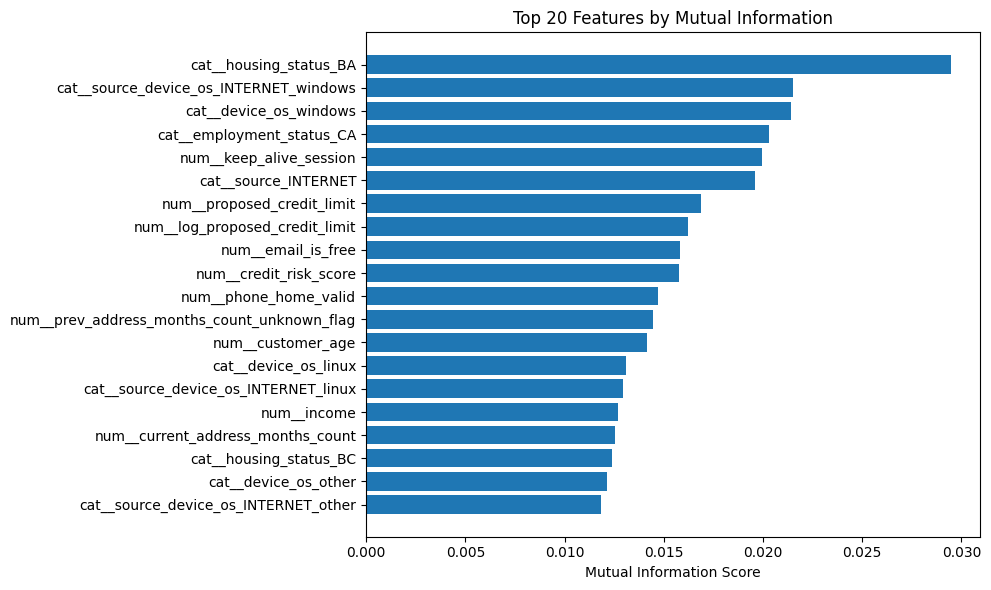

In [ ]:
# Feature selection using mutual information

from sklearn.feature_selection import mutual_info_classif

# Create a manageable training sample
train_sample = X_train.copy()
train_sample[TARGET_COL] = y_train.values

# Use a stratified-like sample by taking all fraud cases and a sample of legitimate cases
fraud_cases = train_sample[train_sample[TARGET_COL] == 1]
legit_cases = train_sample[train_sample[TARGET_COL] == 0].sample(
    n=min(100000, (train_sample[TARGET_COL] == 0).sum()),
    random_state=SEED
)

feature_selection_sample = pd.concat([fraud_cases, legit_cases], axis=0).sample(
    frac=1,
    random_state=SEED
)

X_fs = feature_selection_sample.drop(columns=[TARGET_COL])
y_fs = feature_selection_sample[TARGET_COL]

# Fit preprocessing on sample
X_fs_processed = preprocessor.fit_transform(X_fs)

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Compute mutual information
mi_scores = mutual_info_classif(
    X_fs_processed,
    y_fs,
    random_state=SEED
)

mi_summary = pd.DataFrame({
    "feature": feature_names,
    "mutual_information_score": mi_scores
}).sort_values("mutual_information_score", ascending=False)

display(mi_summary.head(30))

plt.figure(figsize=(10, 6))
top_mi = mi_summary.head(20).sort_values("mutual_information_score")
plt.barh(top_mi["feature"], top_mi["mutual_information_score"])
plt.title("Top 20 Features by Mutual Information")
plt.xlabel("Mutual Information Score")
plt.tight_layout()
plt.show()

**o. Preliminary Model-Based Feature Importance**

In addition to mutual information, a preliminary model-based feature importance analysis will be performed using a Random Forest model on the feature selection sample. This is not yet the final model implementation. It is used in Step 3 only to understand which features may be useful and to support the feature engineering report.

This helps satisfy the requirement for feature importance or explainability before moving to full model comparison in Step 4.

,feature,importance
56,cat__housing_status_BA,0.154496
68,cat__device_os_windows,0.088124
85,cat__source_device_os_INTERNET_windows,0.075172
3,num__current_address_months_count,0.048996
26,num__prev_address_months_count_unknown_flag,0.045663
22,num__keep_alive_session,0.040433
13,num__credit_risk_score,0.032015
38,num__log_proposed_credit_limit,0.030353
80,cat__credit_risk_band_very_high,0.028783
19,num__proposed_credit_limit,0.027125


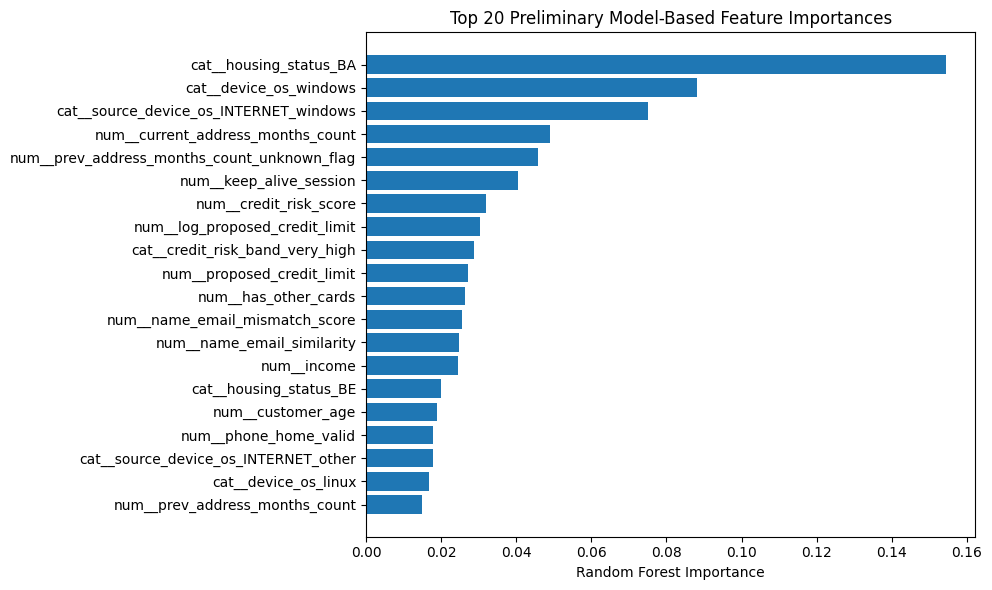

In [ ]:
# Preliminary model-based feature importance

from sklearn.ensemble import RandomForestClassifier

rf_importance_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    class_weight="balanced_subsample",
    random_state=SEED,
    n_jobs=-1
)

rf_importance_model.fit(X_fs_processed, y_fs)

importance_summary = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_importance_model.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_summary.head(30))

plt.figure(figsize=(10, 6))
top_imp = importance_summary.head(20).sort_values("importance")
plt.barh(top_imp["feature"], top_imp["importance"])
plt.title("Top 20 Preliminary Model-Based Feature Importances")
plt.xlabel("Random Forest Importance")
plt.tight_layout()
plt.show()

**p. SHAP Explainability Preview**

SHAP analysis will be emphasized later in the Ethical AI and Bias Auditing section. Since SHAP can be computationally expensive, this section uses a small sample.

/tmp/ipykernel_1441/2026397569.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


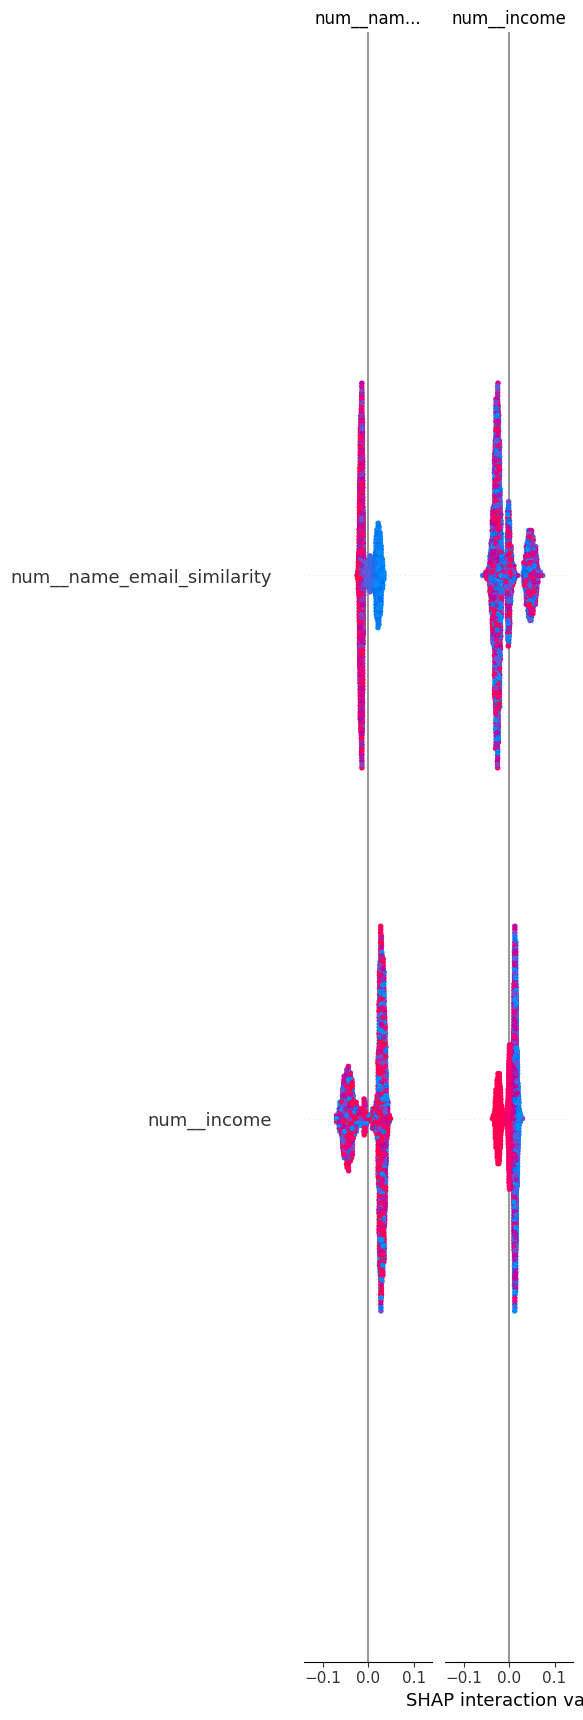

In [ ]:
# SHAP explainability preview

import shap

# Use a smaller sample for SHAP
shap_sample_size = min(2000, X_fs_processed.shape[0])
X_shap_sample = X_fs_processed[:shap_sample_size]

explainer = shap.TreeExplainer(rf_importance_model)
shap_values = explainer.shap_values(X_shap_sample)

# For binary classification, use SHAP values for the fraud class if available
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values

shap.summary_plot(
    shap_values_to_plot,
    X_shap_sample,
    feature_names=feature_names,
    max_display=20
)

**q. Dimensionality Reduction Using PCA**

This project will use Principal Component Analysis (PCA) for visualization and structure review. PCA is not necessarily used as the final model input because explainability is important in fraud detection, and PCA components are harder to interpret than original features. However, PCA is useful for visualizing whether fraudulent and legitimate applications show separable patterns in lower-dimensional space.

Explained variance ratio: [0.97898301 0.01663029]
Total explained variance: 0.9956133003944448


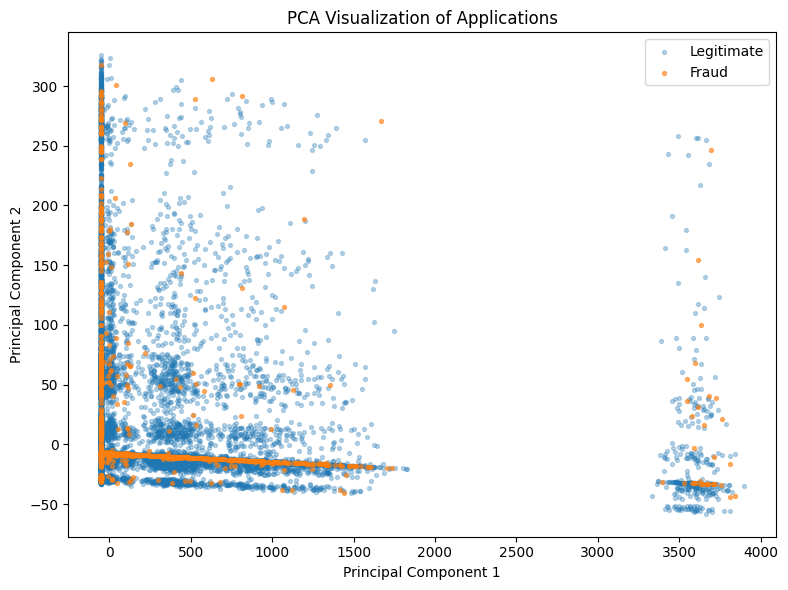

In [ ]:
# PCA for dimensionality reduction and visualization

from sklearn.decomposition import PCA

# Use the same feature selection sample for PCA
pca = PCA(n_components=2, random_state=SEED)

X_pca = pca.fit_transform(X_fs_processed)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "fraud_bool": y_fs.values
})

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(8, 6))
plt.scatter(
    pca_df.loc[pca_df["fraud_bool"] == 0, "PC1"],
    pca_df.loc[pca_df["fraud_bool"] == 0, "PC2"],
    alpha=0.3,
    s=8,
    label="Legitimate"
)
plt.scatter(
    pca_df.loc[pca_df["fraud_bool"] == 1, "PC1"],
    pca_df.loc[pca_df["fraud_bool"] == 1, "PC2"],
    alpha=0.6,
    s=8,
    label="Fraud"
)
plt.title("PCA Visualization of Applications")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()

**r. Process Variant II Using the Same Pipeline Logic**

Variant II will not be merged with Base. It will be processed using the same feature engineering function and preprocessing logic to support a robustness and fairness stress test later. This ensures that performance differences between Base and Variant II are due to dataset differences, not inconsistent preprocessing.

In [ ]:
# Prepare Variant II for future robustness and fairness testing

X_variant_ii = variant_ii_fe.drop(columns=[TARGET_COL])
y_variant_ii = variant_ii_fe[TARGET_COL]

# Important:
# Do not fit preprocessing on Variant II.
# The preprocessor should be fitted on Base training data only in model training.
# Variant II should be transformed using the fitted preprocessor later.

print("Variant II feature set shape:", X_variant_ii.shape)
print("Variant II target shape:", y_variant_ii.shape)
print("Variant II fraud rate:", round(y_variant_ii.mean() * 100, 4), "%")

Variant II feature set shape: (1000000, 52)
Variant II target shape: (1000000,)
Variant II fraud rate: 1.1029 %


**s. Save Processed Feature Datasets and Reports**

To make the project reproducible, the engineered datasets and Step 3 summary outputs should be saved in the data/processed/ and reports/ folders. The raw datasets remain unchanged in data/raw/.

In [ ]:
# Save processed datasets and Step 3 outputs

from pathlib import Path

processed_dir = Path("data/processed")
reports_dir = Path("reports")

processed_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

# Save engineered datasets
# Parquet is preferred for efficiency. CSV fallback is provided if parquet engine is unavailable.
try:
    base_fe.to_parquet(processed_dir / "base_feature_engineered.parquet", index=False)
    variant_ii_fe.to_parquet(processed_dir / "variant_ii_feature_engineered.parquet", index=False)
    print("Feature-engineered datasets saved as parquet.")
except Exception as e:
    print("Parquet save failed. Saving as CSV instead.")
    print("Reason:", e)
    base_fe.to_csv(processed_dir / "base_feature_engineered.csv", index=False)
    variant_ii_fe.to_csv(processed_dir / "variant_ii_feature_engineered.csv", index=False)

# Save selected reports
outlier_summary_base.to_csv(reports_dir / "step3_outlier_summary_base.csv", index=False)
mi_summary.to_csv(reports_dir / "step3_mutual_information_scores.csv", index=False)
importance_summary.to_csv(reports_dir / "step3_model_based_feature_importance.csv", index=False)

print("Step 3 reports saved.")

Feature-engineered datasets saved as parquet.
Step 3 reports saved.


**Summary**


The preprocessing workflow expanded each dataset from 32 to 53 columns by adding missingness indicators, identity-consistency measures, address-history features, velocity ratios, amount transformations, device-risk flags, age groups, credit-risk bands, and source-device interactions. Sentinel values were preserved through indicator variables and then converted to missing values for median imputation. Outliers were retained and handled through log transformations and RobustScaler, protecting potential fraud signals from indiscriminate deletion.


EDA identified meaningful segment differences. Fraud prevalence was highest for housing status BA (3.75%), employment status CC (2.47%), Windows devices (2.47%), payment type AC (1.67%), and TELEAPP applications (1.59%). Engineered indicators also separated risk: multiple emails on one device had a fraud rate of 4.09%, low name-email similarity 1.91%, and the oldest age bands exceeded 4%. Fraud prevalence increased over time from 0.87%-1.18% in most early months to 1.34% in validation month 6 and 1.47% in test month 7, supporting temporal rather than random holdout validation.


The final split contained 794,989 training, 108,168 validation, and 96,843 test records. Mutual information and Random Forest importance consistently highlighted housing status, device operating system, source-device combinations, address history, keep-alive behavior, credit risk, proposed credit limit, income, and age. PCA explained 99.56% of the sampled transformed variance in two components, but it was retained mainly for visualization because original features are more interpretable for fraud governance.


One issue was identified for later sensitivity testing: credit_risk_band was generated with dataset-wide quantiles before the temporal split. Step 5 therefore evaluates the final model without this feature to determine whether the reported performance materially depends on this possible preprocessing leakage.